In [1]:
import os
import sys
os.environ['PYTHONWARNINGS'] = 'ignore'
class NullWriter:
    def write(self, msg):
        pass
    def flush(self):
        pass
sys.stderr = NullWriter()

In [2]:

import scanpy as sc, matplotlib.pyplot as plt, pandas as pd, numpy as np, celldyc as cdc, scvelo as scv, cellrank as cr
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

computing neighbors
    finished (0:00:07) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:01) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


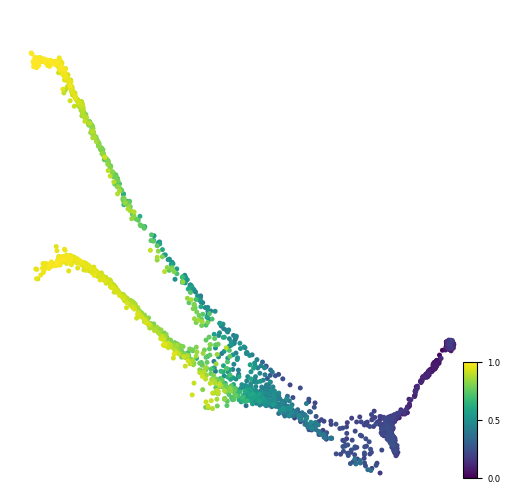

  0%|          | 0/2341 [00:00<?, ?cell/s]

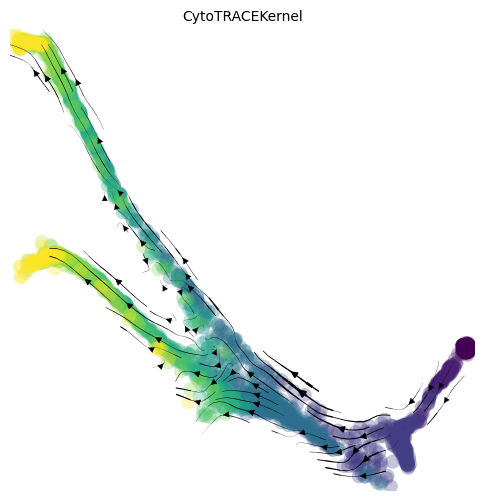

In [3]:
adata = cdc.datasets.zebrafish()
new_cat = adata.obs['Stage'].cat.categories.str.split('-').str[0]
adata.obs['time'] = pd.Categorical(
        adata.obs['Stage'].astype(str).str.split('-').str[0],
        categories=new_cat.unique(), ordered=True)
sc.pp.filter_genes(adata, min_cells=10)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata)
adata.layers['spliced'] = adata.X
adata.layers['unspliced'] = adata.X
scv.pp.moments(adata, n_pcs=30, n_neighbors=30)
ctk = cr.kernels.CytoTRACEKernel(adata).compute_cytotrace(layer="Ms")
adata_cdc=adata.copy()
fig, ax = plt.subplots(figsize=(6,6))
sc.pl.embedding(
    adata,
    color="ct_pseudotime",
    basis="force_directed",
    color_map="viridis",
    frameon=False,
    ax=ax,
    show=False,
    title=" ",
    colorbar_loc=None
)
cax = inset_axes(ax,
                width="3%",   
                height="25%",  
                loc='lower right',
                bbox_to_anchor=(0.02, 0.02, 1, 1),
                bbox_transform=ax.transAxes)
norm = plt.Normalize(vmin=0, vmax=1)
sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, cax=cax)
cbar.set_ticks([0, 0.5, 1])  
cbar.ax.tick_params(labelsize=6) 
plt.show()

ctk.compute_transition_matrix(threshold_scheme="soft", nu=0.5)
ctk.plot_projection(basis="force_directed", color="Stage", legend_loc='none',show=False,title="CytoTRACEKernel",figsize=(6,6),palette="viridis")
ax = plt.gca()
ax.grid(False)
plt.show()

Training with early stop (max_epochs=500, patience=40)
epoch   1:loss=0.912558,trend_loss=0.897394,time_loss=0.151641
epoch  51:loss=0.563501,trend_loss=0.562695,time_loss=0.008068
epoch 101:loss=0.531260,trend_loss=0.530769,time_loss=0.004908
epoch 151:loss=0.523123,trend_loss=0.522729,time_loss=0.003932
epoch 201:loss=0.514882,trend_loss=0.514564,time_loss=0.003185
Early stopping at epoch 221


  0%|          | 0/2341 [00:00<?, ?cells/s]

computing velocity graph
finished.


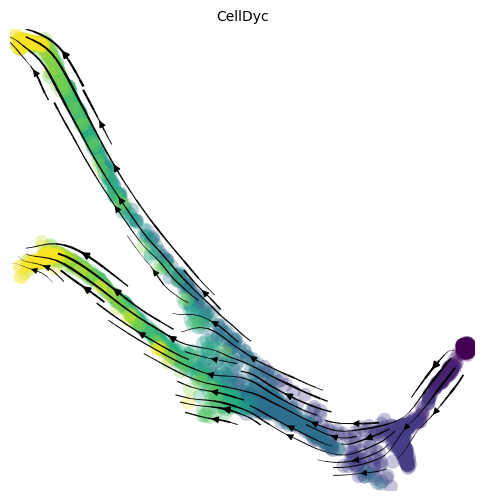

computing velocity embedding
finished.


In [4]:
cdc.tl.recover_dyc(adata_cdc,time_key="ct_pseudotime")
cdc.pl.plot_velocity_projection(adata_cdc, basis='force_directed', color='Stage', legend_loc='none',show=True,title="CellDyc",figsize=(6,6),palette="viridis")

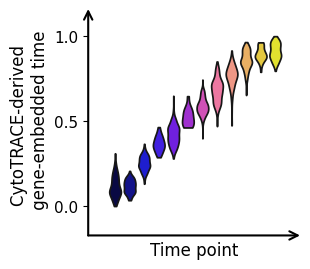

<Axes: xlabel='Time point', ylabel='CytoTRACE-derived \n gene-embedded time'>

In [5]:
cdc.pl.getime_violin(adata_cdc, 'getime', 'time', palette="gnuplot2",ylabel="CytoTRACE-derived \n gene-embedded time")

  0%|          | 0/2341 [00:00<?, ?cell/s]

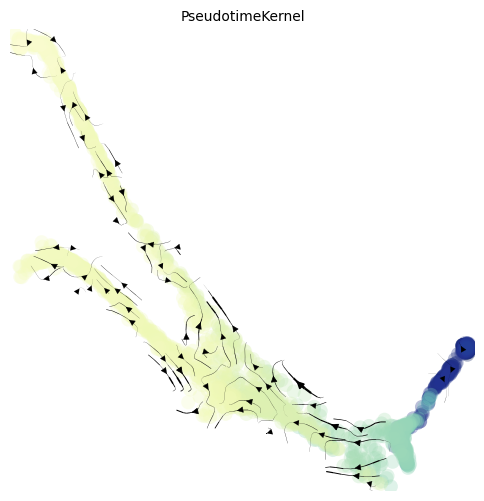

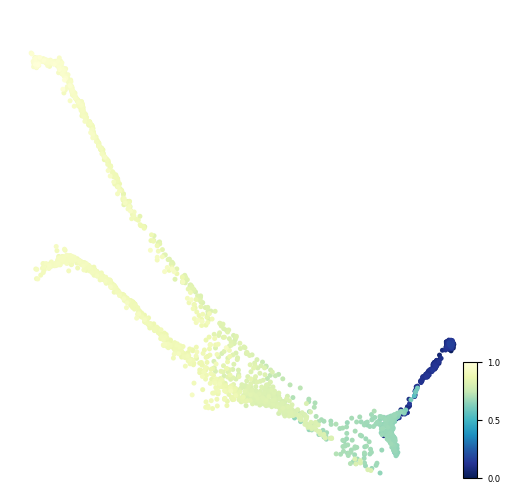

In [ ]:
adata = cdc.datasets.zebrafish()
new_cat = adata.obs['Stage'].cat.categories.str.split('-').str[0]
adata.obs['time'] = pd.Categorical(
        adata.obs['Stage'].astype(str).str.split('-').str[0],
        categories=new_cat.unique(), ordered=True)
adata=cdc.tl.preprocess(adata)
adata_cdc = adata.copy()
start_cell_index = np.where(adata.obs['Stage'] == '03.3-HIGH')[0][0]
adata.uns['iroot'] = start_cell_index
sc.tl.diffmap(adata)
sc.tl.dpt(adata)
pk = cr.kernels.PseudotimeKernel(adata, time_key="dpt_pseudotime")
pk.compute_transition_matrix()
pk.write_to_adata()
pk.plot_projection(basis="force_directed", color="dpt_pseudotime", legend_loc='none',show=False,title="PseudotimeKernel",figsize=(6,6),cmap="YlGnBu_r",colorbar=False)
ax = plt.gca()
ax.grid(False)
plt.show()

fig, ax = plt.subplots(figsize=(6,6))
sc.pl.embedding(
    adata,
    color="dpt_pseudotime",
    basis="force_directed",
    color_map="YlGnBu_r",
    frameon=False,
    ax=ax,
    show=False,
    title=" ",
    colorbar_loc=None
)
cax = inset_axes(ax,
            width="3%",    
            height="25%",  
            loc='lower right',
            bbox_to_anchor=(0.02, 0.02, 1, 1),
            bbox_transform=ax.transAxes)

data_values = adata.obs["dpt_pseudotime"].values
vmin = data_values.min()
vmax = data_values.max()
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(cmap='YlGnBu_r', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, cax=cax)
cbar.set_ticks([vmin, (vmin + vmax)/2, vmax])
cbar.set_ticklabels([
    f'{vmin:.1f}', 
    f'{(vmin + vmax)/2:.1f}', 
    f'{vmax:.1f}'
])
cbar.ax.tick_params(labelsize=6) 
plt.show()


Training with early stop (max_epochs=500, patience=40)
epoch   1:loss=0.868949,trend_loss=0.857738,time_loss=0.112110
epoch  51:loss=0.447456,trend_loss=0.446434,time_loss=0.010223
epoch 101:loss=0.393968,trend_loss=0.393142,time_loss=0.008256
epoch 151:loss=0.397204,trend_loss=0.396447,time_loss=0.007570
epoch 201:loss=0.391299,trend_loss=0.390561,time_loss=0.007379
epoch 251:loss=0.381514,trend_loss=0.380788,time_loss=0.007263
epoch 301:loss=0.377166,trend_loss=0.376433,time_loss=0.007331
Early stopping at epoch 307


  0%|          | 0/2341 [00:00<?, ?cells/s]

computing velocity graph
finished.
computing velocity embedding
finished.


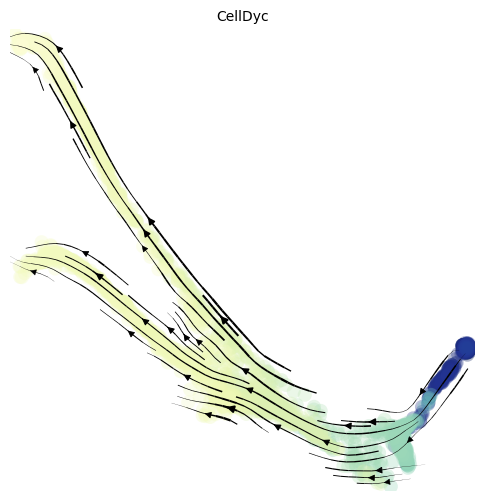

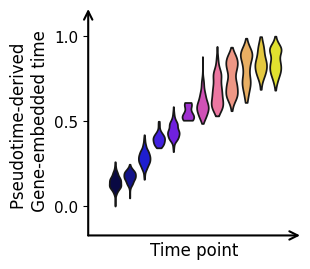

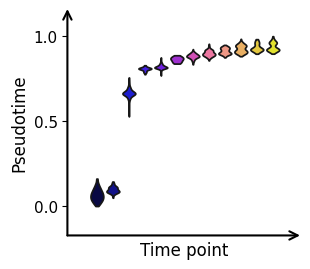

<Axes: xlabel='Time point', ylabel='Pseudotime'>

In [7]:
adata_cdc.obs["dpt_pseudotime"]=adata.obs["dpt_pseudotime"]
cdc.tl.recover_dyc(adata,time_key="dpt_pseudotime")
cdc.pl.plot_velocity_projection(adata, basis='force_directed', color='dpt_pseudotime', legend_loc='none',show=False,title="CellDyc",figsize=(6,6),cmap="YlGnBu_r",colorbar=False)
cdc.pl.getime_violin(adata, 'getime', 'time', palette="gnuplot2",ylabel="Pseudotime-derived \n Gene-embedded time")
cdc.pl.getime_violin(adata, 'dpt_pseudotime', 'time', palette="gnuplot2",ylabel="Pseudotime")